# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')

df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


# Cek Struktur Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [4]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


# Hitung Total Penjualan

In [5]:
total_sales = df['SALES'].sum()

print("Total Penjualan:", total_sales)

Total Penjualan: 10032628.85


# Cari Produk Paling Laris

In [6]:
top_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

top_product

,SALES
PRODUCTLINE,
Classic Cars,3919615.66
Vintage Cars,1903150.84
Motorcycles,1166388.34
Trucks and Buses,1127789.84
Planes,975003.57
Ships,714437.13
Trains,226243.47


# Visualisasi Produk Terlaris

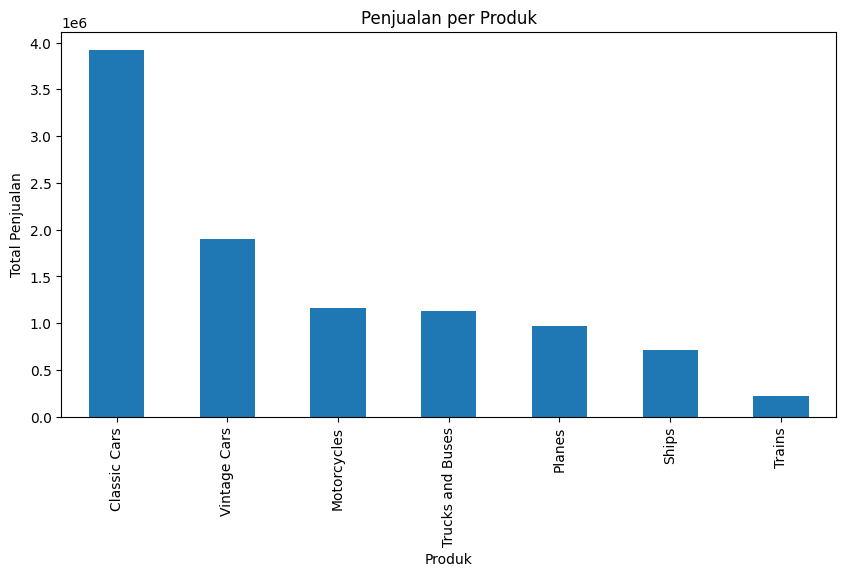

In [7]:
plt.figure(figsize=(10,5))

top_product.plot(kind='bar')

plt.title("Penjualan per Produk")
plt.xlabel("Produk")
plt.ylabel("Total Penjualan")

plt.show()

# Analisis Penjualan per Bulan

In [8]:
sales_per_month = df.groupby('MONTH_ID')['SALES'].sum().sort_index()

sales_per_month

,SALES
MONTH_ID,
1,785874.44
2,810441.90
3,754501.39
4,669390.96
5,923972.56
6,454756.78
7,514875.97
8,659310.57
9,584724.27


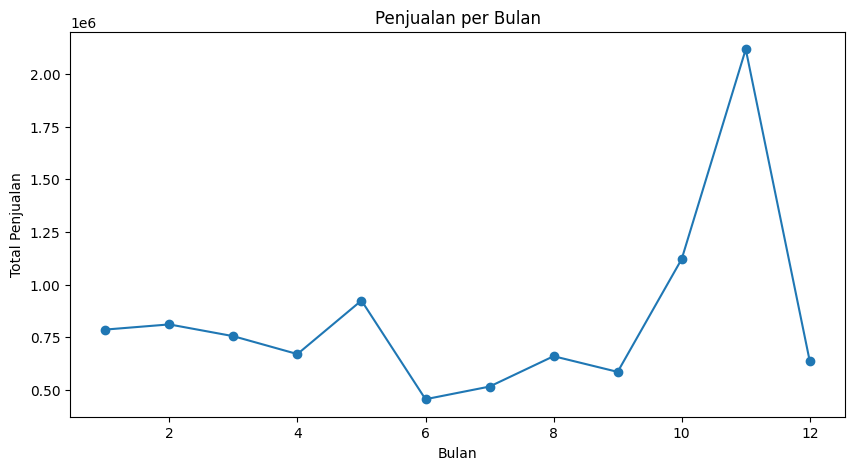

In [9]:
# Visualisasi

plt.figure(figsize=(10,5))

sales_per_month.plot(kind='line', marker='o')

plt.title("Penjualan per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Total Penjualan")

plt.show()

# Negara dengan Penjualan Terbesar

In [10]:
sales_country = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False)

sales_country.head()

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46


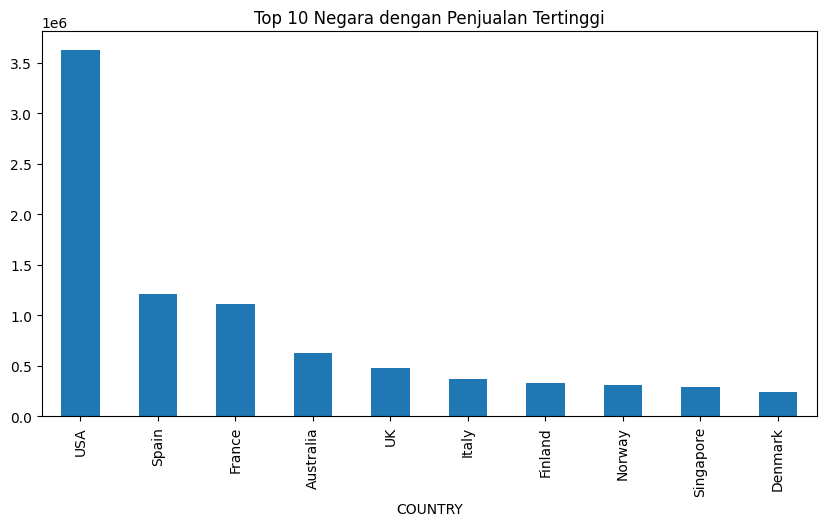

In [11]:
# Visualisasi
plt.figure(figsize=(10,5))

sales_country.head(10).plot(kind='bar')

plt.title("Top 10 Negara dengan Penjualan Tertinggi")

plt.show()

# Insight

In [12]:
print("Produk paling laris:", top_product.idxmax())
print("Bulan terbaik:", sales_per_month.idxmax())
print("Negara terbaik:", sales_country.idxmax())

Produk paling laris: Classic Cars
Bulan terbaik: 11
Negara terbaik: USA


# Simpan Hasil ke Excel

In [13]:
top_product.to_excel("top_product.xlsx")
sales_country.to_excel("sales_country.xlsx")
sales_per_month.to_excel("sales_per_month.xlsx")

# Tambahan untuk status penjualan

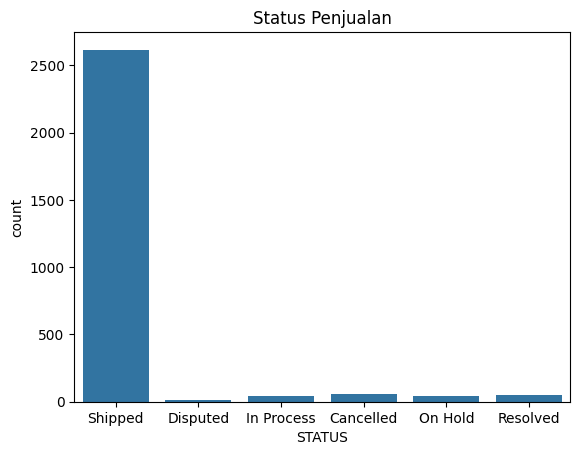

In [14]:
sns.countplot(x='STATUS', data=df)

plt.title("Status Penjualan")

plt.show()

# **Machine Learning**

# Import Library Machine Learning

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Pilih Fitur untuk Prediksi
- QUANTITYORDERED
- PRICEEACH
- MONTH_ID
- YEAR_ID

In [16]:
features = ['QUANTITYORDERED', 'PRICEEACH', 'MONTH_ID', 'YEAR_ID']
X = df[features]

y = df['SALES']

# Split Data Training dan Testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Membuat Model

In [18]:
model = LinearRegression()

# Training Model

In [19]:
model.fit(X_train, y_train)

LinearRegression()

# Prediksi

In [20]:
y_pred = model.predict(X_test)

# Evaluasi Model

In [21]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 772.9131192840364
R2 Score: 0.6886824244296251


# Memandingkan Prediksi vs Asli

In [22]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result.head(10)

,Actual,Predicted
1091,1536.57,1477.563297
2328,2168.50,2686.136835
1474,4351.23,4892.417915
1437,3880.20,4912.259366
1105,3042.68,3559.724727
239,7969.36,5901.511811
1366,7827.30,4890.364477
1407,1672.10,1657.350711
1858,2328.66,2519.521657
1061,8289.05,6504.725530


# Visualisasi Prediksi

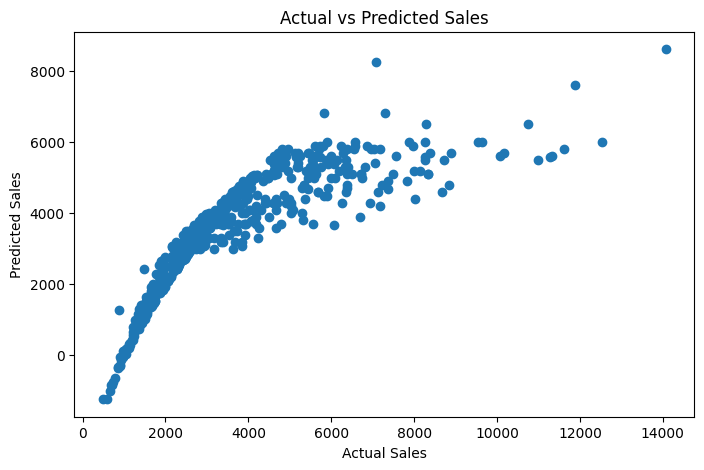

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# Memprediski Data Baru

In [26]:
def predict_sales(quantity, price, month, year):
    new_data = pd.DataFrame({
        'QUANTITYORDERED': [quantity],
        'PRICEEACH': [price],
        'MONTH_ID': [month],
        'YEAR_ID': [year]
    })

    prediction = model.predict(new_data)

    return prediction[0]


hasil = predict_sales(30, 100, 5, 2004)

print("Prediksi:", hasil)

Prediksi: 3982.227265715661


# Simpan MOdel

In [27]:
import pickle

with open("model_sales.pkl", "wb") as file:
    pickle.dump(model, file)

In [28]:
print("Model berhasil dibuat untuk memprediksi penjualan berdasarkan:")
print("- Quantity Ordered")
print("- Price Each")
print("- Month")
print("- Year")

Model berhasil dibuat untuk memprediksi penjualan berdasarkan:
- Quantity Ordered
- Price Each
- Month
- Year
